# 03 - Survival Modeling Foundations

This notebook provides a clean survival modeling workflow:
1. Build censor-aware targets
2. Train baseline survival models
3. Evaluate with C-index and weighted Brier
4. Generate horizon probabilities with monotonic checks

In [36]:
from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index

DATASET_DIR = Path('../dataset')
SUBMISSIONS_DIR = Path('../submissions')
SUBMISSIONS_DIR.mkdir(parents=True, exist_ok=True)

In [37]:
train = pd.read_csv(DATASET_DIR / 'train.csv').fillna(0)
test = pd.read_csv(DATASET_DIR / 'test.csv').fillna(0)

feature_cols = [c for c in train.columns if c not in ['event_id', 'time_to_hit_hours', 'event']]
print('train rows:', len(train), 'test rows:', len(test), 'features:', len(feature_cols))

train rows: 221 test rows: 95 features: 34


## Why Test Interaction Terms Here

The baseline survival model already captures the strongest direct signal from distance to the nearest evacuation zone. That does not mean the other physical features are useless. Speed, direction, and growth can still matter when two fires are similarly close but behave differently.

Interaction terms are tested here for one reason only: to check whether the model improves when those signals are combined into context-aware features rather than used separately. This is a controlled comparison, not a blanket replacement for the original features.

The interaction-enhanced version should be kept only if it improves cross-validated ranking and calibration in a stable way. If the gain is small, inconsistent, or only appears in one fold, the baseline feature set remains the safer default.

In [38]:
def build_interaction_features(df):
    df = df.copy()
    df['time_to_contact'] = df['dist_min_ci_0_5h'] / (df['closing_speed_m_per_h'].abs() + 1.0)
    # threat_index removed: very low variance triggered convergence warnings in CoxPH.
    df['growth_pressure'] = df['area_growth_rate_ha_per_h'] * df['alignment_abs']
    df['directional_urgency'] = df['along_track_speed'] * df['alignment_abs']
    return df.fillna(0)

base_features = [c for c in train.columns if c not in ['event_id', 'time_to_hit_hours', 'event']]
interaction_train = build_interaction_features(train)
interaction_features = [c for c in interaction_train.columns if c not in ['event_id', 'time_to_hit_hours', 'event']]

print('baseline feature count:', len(base_features))
print('interaction-enhanced feature count:', len(interaction_features))
print('interaction-only additions:', sorted(set(interaction_features) - set(base_features)))

baseline feature count: 34
interaction-enhanced feature count: 37
interaction-only additions: ['directional_urgency', 'growth_pressure', 'time_to_contact']


In [39]:
def brier_score_at_horizon(prob_pred, event_true, time_true, horizon):
    mask = (event_true == 1) | (time_true >= horizon)
    y_h = ((event_true == 1) & (time_true <= horizon)).astype(int)
    return np.mean((prob_pred[mask] - y_h[mask]) ** 2)

def weighted_brier(df_probs, event_true, time_true):
    b24 = brier_score_at_horizon(df_probs['prob_24h'].values, event_true, time_true, 24)
    b48 = brier_score_at_horizon(df_probs['prob_48h'].values, event_true, time_true, 48)
    b72 = brier_score_at_horizon(df_probs['prob_72h'].values, event_true, time_true, 72)
    return 0.3 * b24 + 0.4 * b48 + 0.3 * b72

In [40]:
def evaluate_feature_set(df, feature_list):
    kf_local = KFold(n_splits=5, shuffle=True, random_state=42)
    c_scores_local, b_scores_local = [], []

    for tr_idx, va_idx in kf_local.split(df):
        tr = df.iloc[tr_idx]
        va = df.iloc[va_idx]

        cph = CoxPHFitter(penalizer=0.1)
        cph.fit(tr[feature_list + ['time_to_hit_hours', 'event']], duration_col='time_to_hit_hours', event_col='event')

        risk = cph.predict_partial_hazard(va[feature_list]).values.ravel()
        cidx = concordance_index(va['time_to_hit_hours'], -risk, va['event'])
        c_scores_local.append(cidx)

        surv = cph.predict_survival_function(va[feature_list], times=[12, 24, 48, 72])
        probs = pd.DataFrame(index=va.index)
        probs['prob_12h'] = 1 - surv.loc[12].values
        probs['prob_24h'] = 1 - surv.loc[24].values
        probs['prob_48h'] = 1 - surv.loc[48].values
        probs['prob_72h'] = 1 - surv.loc[72].values

        b_scores_local.append(weighted_brier(probs[['prob_24h', 'prob_48h', 'prob_72h']], va['event'].values, va['time_to_hit_hours'].values))

    mean_c_local = float(np.mean(c_scores_local))
    mean_b_local = float(np.mean(b_scores_local))
    hybrid_local = 0.3 * mean_c_local + 0.7 * (1 - mean_b_local)
    return mean_c_local, mean_b_local, hybrid_local

baseline_c, baseline_b, baseline_h = evaluate_feature_set(train, base_features)
interaction_c, interaction_b, interaction_h = evaluate_feature_set(interaction_train, interaction_features)

comparison = pd.DataFrame([
    {'feature_set': 'baseline', 'c_index': baseline_c, 'weighted_brier': baseline_b, 'hybrid': baseline_h},
    {'feature_set': 'interaction_enhanced', 'c_index': interaction_c, 'weighted_brier': interaction_b, 'hybrid': interaction_h},
])
display(comparison)

use_interaction_set = interaction_h >= baseline_h
chosen_df = interaction_train if use_interaction_set else train
chosen_features = interaction_features if use_interaction_set else base_features

print('selected feature set:', 'interaction_enhanced' if use_interaction_set else 'baseline')
print('selected feature count:', len(chosen_features))

,feature_set,c_index,weighted_brier,hybrid
0,baseline,0.841547,0.133739,0.858847
1,interaction_enhanced,0.861953,0.114386,0.878515


selected feature set: interaction_enhanced
selected feature count: 37


## Probability Calibration and Reliability

The survival model already provides horizon probabilities, but those probabilities can still be too optimistic or too conservative. Calibration checks whether predicted probabilities match observed frequencies.

This step uses out-of-fold predictions to reduce overfitting. A safeguard is also applied per horizon:
- If the usable calibration set contains only one class, isotonic calibration is skipped.
- If isotonic does not improve Brier on out-of-fold predictions, the raw probabilities are kept.

This keeps calibration conservative and prevents degenerate behavior (for example, a horizon where all usable rows are positive).

,horizon,usable_rows,positive_rows,raw_brier,post_cal_brier,decision
0,12,215,49,0.103498,0.089187,isotonic_used
1,24,196,63,0.132051,0.110804,isotonic_used
2,48,166,66,0.134377,0.112409,isotonic_used
3,72,69,69,0.078767,0.078767,single_class_skip


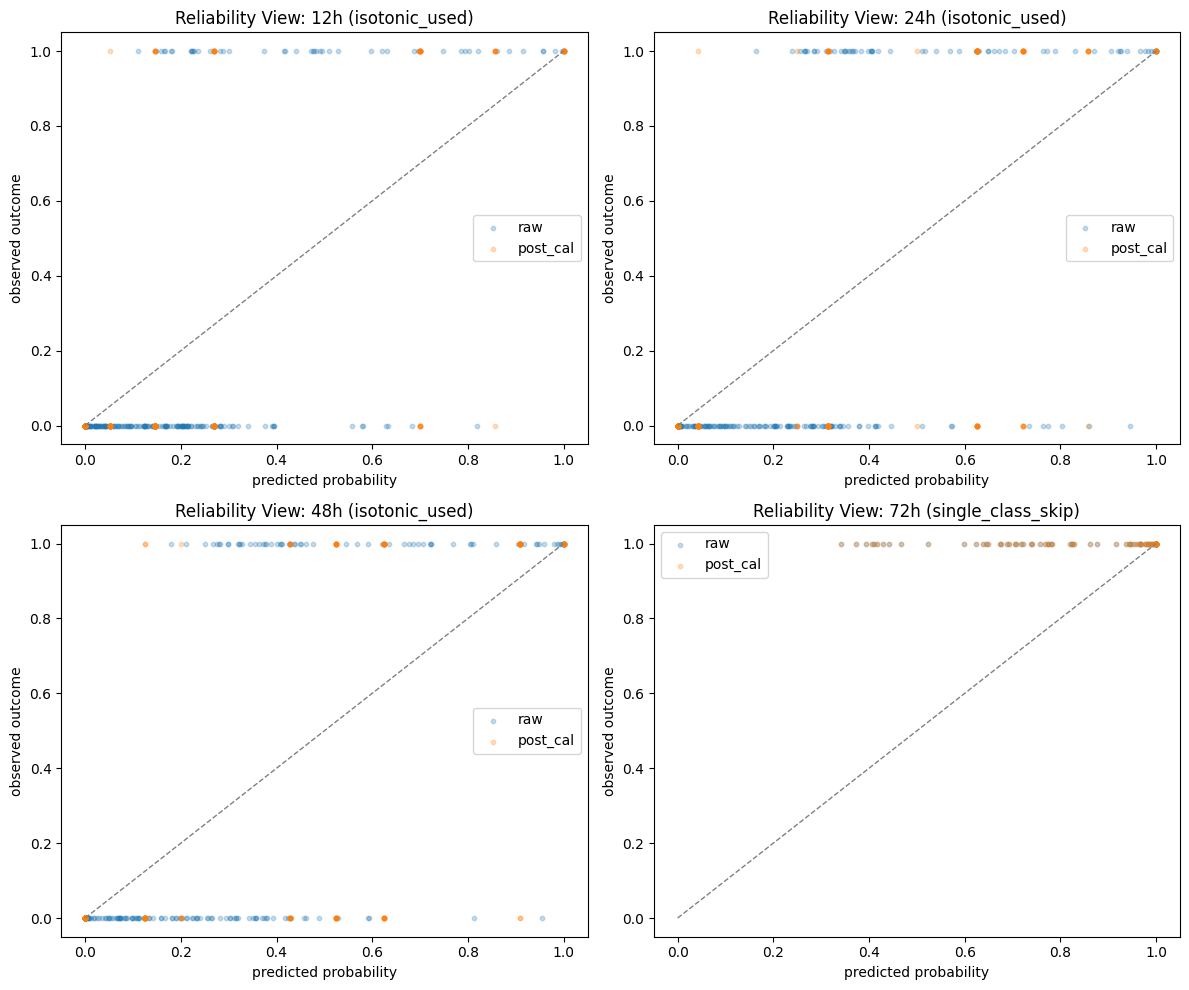

saved calibrated submission: ..\submissions\submission_survival_foundation_calibrated.csv
calibration usage by horizon: {12: True, 24: True, 48: True, 72: False}


In [41]:
from sklearn.isotonic import IsotonicRegression
import matplotlib.pyplot as plt

# Build out-of-fold horizon probabilities so calibration is fitted on held-out predictions.
oof_probs = {12: np.zeros(len(chosen_df)), 24: np.zeros(len(chosen_df)), 48: np.zeros(len(chosen_df)), 72: np.zeros(len(chosen_df))}

for tr_idx, va_idx in kf.split(chosen_df):
    tr = chosen_df.iloc[tr_idx]
    va = chosen_df.iloc[va_idx]

    cph = CoxPHFitter(penalizer=0.1)
    cph.fit(tr[chosen_features + ['time_to_hit_hours', 'event']], duration_col='time_to_hit_hours', event_col='event')

    surv = cph.predict_survival_function(va[chosen_features], times=[12, 24, 48, 72])
    oof_probs[12][va_idx] = 1 - surv.loc[12].values
    oof_probs[24][va_idx] = 1 - surv.loc[24].values
    oof_probs[48][va_idx] = 1 - surv.loc[48].values
    oof_probs[72][va_idx] = 1 - surv.loc[72].values

calibrators = {}
calibrated_oof = {}
calibration_summary = []
use_calibration = {}

for horizon in [12, 24, 48, 72]:
    y_h = ((chosen_df['event'] == 1) & (chosen_df['time_to_hit_hours'] <= horizon)).astype(int)
    usable = (chosen_df['event'] == 1) | (chosen_df['time_to_hit_hours'] >= horizon)

    raw_brier = np.mean((oof_probs[horizon][usable] - y_h[usable]) ** 2)

    # Default: identity mapping (no calibration)
    calibrators[horizon] = None
    calibrated_oof[horizon] = oof_probs[horizon].copy()
    use_calibration[horizon] = False
    decision = 'raw_only'

    # Calibrate only when both classes are present in usable labels.
    if y_h[usable].nunique() > 1:
        iso = IsotonicRegression(out_of_bounds='clip')
        iso.fit(oof_probs[horizon][usable], y_h[usable])

        candidate = calibrated_oof[horizon].copy()
        candidate[usable] = iso.transform(oof_probs[horizon][usable])
        cal_brier = np.mean((candidate[usable] - y_h[usable]) ** 2)

        # Keep isotonic only if it improves OOF Brier.
        if cal_brier < raw_brier:
            calibrators[horizon] = iso
            calibrated_oof[horizon] = candidate
            use_calibration[horizon] = True
            decision = 'isotonic_used'
        else:
            cal_brier = raw_brier
            decision = 'isotonic_rejected'
    else:
        cal_brier = raw_brier
        decision = 'single_class_skip'

    calibration_summary.append((horizon, int(usable.sum()), int(y_h[usable].sum()), raw_brier, cal_brier, decision))

calibration_df = pd.DataFrame(
    calibration_summary,
    columns=['horizon', 'usable_rows', 'positive_rows', 'raw_brier', 'post_cal_brier', 'decision']
)
display(calibration_df)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
for i, horizon in enumerate([12, 24, 48, 72]):
    y_h = ((chosen_df['event'] == 1) & (chosen_df['time_to_hit_hours'] <= horizon)).astype(int)
    usable = (chosen_df['event'] == 1) | (chosen_df['time_to_hit_hours'] >= horizon)
    axes[i].plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
    axes[i].scatter(oof_probs[horizon][usable], y_h[usable], s=10, alpha=0.25, label='raw')
    axes[i].scatter(calibrated_oof[horizon][usable], y_h[usable], s=10, alpha=0.25, label='post_cal')
    axes[i].set_title(f'Reliability View: {horizon}h ({calibration_df.loc[calibration_df.horizon==horizon, "decision"].iloc[0]})')
    axes[i].set_xlabel('predicted probability')
    axes[i].set_ylabel('observed outcome')
    axes[i].legend(loc='best')

plt.tight_layout()
plt.show()

# Fit final model and generate predictions on test representation.
final_model = CoxPHFitter(penalizer=0.1)
final_model.fit(chosen_df[chosen_features + ['time_to_hit_hours', 'event']], duration_col='time_to_hit_hours', event_col='event')

test_representation = build_interaction_features(test) if use_interaction_set else test
final_surv = final_model.predict_survival_function(test_representation[chosen_features], times=[12, 24, 48, 72])

final_probs = pd.DataFrame({'event_id': test['event_id']})
for horizon in [12, 24, 48, 72]:
    raw_pred = 1 - final_surv.loc[horizon].values
    if use_calibration[horizon] and calibrators[horizon] is not None:
        final_probs[f'prob_{horizon}h'] = calibrators[horizon].transform(raw_pred)
    else:
        final_probs[f'prob_{horizon}h'] = raw_pred

cols = ['prob_12h', 'prob_24h', 'prob_48h', 'prob_72h']
final_probs[cols] = np.maximum.accumulate(final_probs[cols].values, axis=1)
final_probs[cols] = final_probs[cols].clip(0, 1)

out_path = SUBMISSIONS_DIR / 'submission_survival_foundation_calibrated.csv'
final_probs.to_csv(out_path, index=False)
print('saved calibrated submission:', out_path)
print('calibration usage by horizon:', use_calibration)

In [42]:
from datetime import datetime, timezone

DOCS_DIR = Path('../docs')
DOCS_DIR.mkdir(parents=True, exist_ok=True)
HISTORY_PATH = DOCS_DIR / 'metrics_history.csv'

# Optional: fill this after a Kaggle submission score is visible.
PUBLIC_SCORE = None

run_record = {
    'timestamp_utc': datetime.now(timezone.utc).isoformat(),
    'selected_feature_set': 'interaction_enhanced' if use_interaction_set else 'baseline',
    'selected_feature_count': len(chosen_features),
    'baseline_c_index': baseline_c,
    'baseline_weighted_brier': baseline_b,
    'baseline_hybrid': baseline_h,
    'selected_c_index': interaction_c if use_interaction_set else baseline_c,
    'selected_weighted_brier': interaction_b if use_interaction_set else baseline_b,
    'selected_hybrid': interaction_h if use_interaction_set else baseline_h,
    'post_cal_brier_12h': float(calibration_df.loc[calibration_df['horizon'] == 12, 'post_cal_brier'].iloc[0]),
    'post_cal_brier_24h': float(calibration_df.loc[calibration_df['horizon'] == 24, 'post_cal_brier'].iloc[0]),
    'post_cal_brier_48h': float(calibration_df.loc[calibration_df['horizon'] == 48, 'post_cal_brier'].iloc[0]),
    'post_cal_brier_72h': float(calibration_df.loc[calibration_df['horizon'] == 72, 'post_cal_brier'].iloc[0]),
    'calibration_12h': bool(use_calibration[12]),
    'calibration_24h': bool(use_calibration[24]),
    'calibration_48h': bool(use_calibration[48]),
    'calibration_72h': bool(use_calibration[72]),
    'post_cal_weighted_brier': 0.3 * float(calibration_df.loc[calibration_df['horizon'] == 24, 'post_cal_brier'].iloc[0])
        + 0.4 * float(calibration_df.loc[calibration_df['horizon'] == 48, 'post_cal_brier'].iloc[0])
        + 0.3 * float(calibration_df.loc[calibration_df['horizon'] == 72, 'post_cal_brier'].iloc[0]),
    'post_cal_est_hybrid': 0.3 * (interaction_c if use_interaction_set else baseline_c)
        + 0.7 * (1 - (
            0.3 * float(calibration_df.loc[calibration_df['horizon'] == 24, 'post_cal_brier'].iloc[0])
            + 0.4 * float(calibration_df.loc[calibration_df['horizon'] == 48, 'post_cal_brier'].iloc[0])
            + 0.3 * float(calibration_df.loc[calibration_df['horizon'] == 72, 'post_cal_brier'].iloc[0])
        )),
    'public_score': PUBLIC_SCORE,
    'submission_file': str(out_path),
}

new_row = pd.DataFrame([run_record])
if HISTORY_PATH.exists():
    history_df = pd.read_csv(HISTORY_PATH)
    history_df = pd.concat([history_df, new_row], ignore_index=True)
else:
    history_df = new_row

history_df.to_csv(HISTORY_PATH, index=False)
print(f'Appended run metrics to: {HISTORY_PATH}')
display(history_df.tail(5))

Appended run metrics to: ..\docs\metrics_history.csv


C:\Users\tehre\AppData\Local\Temp\ipykernel_10616\891006161.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  history_df = pd.concat([history_df, new_row], ignore_index=True)


,timestamp_utc,selected_feature_set,selected_feature_count,baseline_c_index,baseline_weighted_brier,baseline_hybrid,selected_c_index,selected_weighted_brier,selected_hybrid,post_cal_brier_12h,...,post_cal_brier_48h,post_cal_brier_72h,calibration_12h,calibration_24h,calibration_48h,calibration_72h,post_cal_weighted_brier,post_cal_est_hybrid,public_score,submission_file
0,2026-04-26T15:57:45.552808+00:00,interaction_enhanced,37,0.841547,0.133739,0.858847,0.861953,0.114386,0.878515,0.089187,...,0.112409,0.078767,True,True,True,False,0.101835,0.887301,NaN,..\submissions\submission_survival_foundation_...
1,2026-04-26T15:59:14.004699+00:00,interaction_enhanced,37,0.841547,0.133739,0.858847,0.861953,0.114386,0.878515,0.089187,...,0.112409,0.078767,True,True,True,False,0.101835,0.887301,0.9479,..\submissions\submission_survival_foundation_...
2,2026-04-26T16:01:11.045181+00:00,interaction_enhanced,37,0.841547,0.133739,0.858847,0.861953,0.114386,0.878515,0.089187,...,0.112409,0.078767,True,True,True,False,0.101835,0.887301,NaN,..\submissions\submission_survival_foundation_...


## Metrics History Logger

This section appends the current run metrics to a persistent history file in `docs/metrics_history.csv`. It is intended to run after model comparison and calibration so every run is tracked consistently.

Before running this cell, set `PUBLIC_SCORE` after an external submission result is available. Keep it `None` when not available.

## Final Model Output

The calibrated submission is generated above using the feature set that performs better in cross-validation. The notebook now compares baseline and interaction-enhanced features before calibration, so the main modeling path is both measurable and reproducible.